# Cycle 1 — Exploratory Data Analysis

**Dataset:** `data/raw/premier_league_matches.csv`

A complete data exploration pass before any preprocessing — schema audit, distributions, target balance, correlations, outliers, temporal stability, and leakage candidate review.

In [5]:
import sys, os 

_here = os.getcwd()                                       
while not os.path.isdir(os.path.join(_here, 'data')):     
    _p = os.path.dirname(_here)                           
    if _p == _here: raise RuntimeError('project root not found')  
    _here = _p
if _here not in sys.path:
    sys.path.insert(0, _here)                              

from config import Paths, ensure_dirs 
ensure_dirs()                  

## Setup
Load both the raw and processed datasets, confirm their shapes and column types, and verify that the target variable `FTR` has been correctly encoded as a 3-class integer (0 = Away Win, 1 = Draw, 2 = Home Win). 

In [6]:
import pandas as pd                       
import numpy as np                        
import matplotlib.pyplot as plt           
import seaborn as sns                     
import warnings
warnings.filterwarnings('ignore')         
sns.set_style('whitegrid')                

df_raw = pd.read_csv(str(Paths.PL_MATCHES_RAW))       # load original unprocessed CSV (40 columns)
print('Raw shape:', df_raw.shape)                      # expected: (6840, 40)
print('Raw FTR values:', df_raw['FTR'].unique())       # shows H/NH — binary, needs reconstruction

# Raw FTR is binary (H = Home Win, NH = Not Home Win).
# Reconstruct proper 3-class labels from full-time goal counts.
# 2 = Home Win, 1 = Draw, 0 = Away Win
df_raw['FTR_3class'] = np.where(df_raw['FTHG'] > df_raw['FTAG'], 2,   # home goals > away → Home Win
                       np.where(df_raw['FTHG'] == df_raw['FTAG'], 1, 0))  # equal → Draw, else Away Win

df = pd.read_csv(str(Paths.PL_MATCHES_PROCESSED))     # load feature-engineered file — this feeds the model
print('Processed shape:', df.shape)                    # expected: (6840, 35) — 33 features + FTR target + Season
print('Processed FTR values (0=Away,1=Draw,2=Home):', sorted(df['FTR'].unique()))  # confirm 3-class encoding
print()
print(df.dtypes.head(10))                              # inspect first 10 column types — all should be numeric
df.head()                                              # visual spot-check of the first 5 rows

Raw shape: (6840, 40)
Raw FTR values: ['H' 'NH']
Processed shape: (6840, 35)
Processed FTR values (0=Away,1=Draw,2=Home): [np.int64(0), np.int64(1), np.int64(2)]

HomeTeam      int64
AwayTeam      int64
FTR           int64
HTGS          int64
ATGS          int64
HTGC          int64
ATGC          int64
HTP         float64
ATP         float64
HM1           int64
dtype: object


,HomeTeam,AwayTeam,FTR,HTGS,ATGS,HTGC,ATGC,HTP,ATP,HM1,...,HTLossStreak5,ATWinStreak3,ATWinStreak5,ATLossStreak3,ATLossStreak5,HTGD,ATGD,DiffPts,DiffFormPts,Season
0,11,24,2,0,0,0,0,0.0,0.0,0,...,0,0,0,0,0,0.0,0.0,0.0,0.0,2000
1,12,41,2,0,0,0,0,0.0,0.0,0,...,0,0,0,0,0,0.0,0.0,0.0,0.0,2000
2,13,27,0,0,0,0,0,0.0,0.0,0,...,0,0,0,0,0,0.0,0.0,0.0,0.0,2000
3,15,34,1,0,0,0,0,0.0,0.0,0,...,0,0,0,0,0,0.0,0.0,0.0,0.0,2000
4,21,16,2,0,0,0,0,0.0,0.0,0,...,0,0,0,0,0,0.0,0.0,0.0,0.0,2000


## Target Variable: (FTR) Full-Time Result Distribution

Quantify how the three match outcomes are distributed across all 6,840 matches. 
Class imbalance directs affects which evaluation metric is appropriate - hence a model that always predicts Home win would achieve ~46% accuracy. making raw accuracy a misleading benchmark. 


FTR (target) distribution:
FTR
0    1913
1    1751
2    3176
Name: count, dtype: int64

Class proportions:
FTR
0    0.280
1    0.256
2    0.464
Name: proportion, dtype: float64


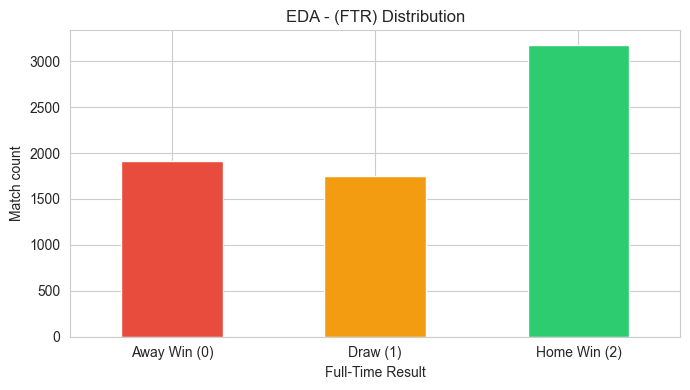

In [7]:
print('FTR (target) distribution:')
print(df['FTR'].value_counts().sort_index())                  # raw match counts per class, sorted Away→Draw→Home
print()
print('Class proportions:')
print(df['FTR'].value_counts(normalize=True).round(3).sort_index())  # fractions summing to 1.0

# Bar chart setip 
fig, ax = plt.subplots(figsize=(7,4))
counts = df['FTR'].value_counts().sort_index()                # ensure bar order: Away(0), Draw(1), Home(2)
counts.plot(kind='bar', color=['#e74c3c','#f39c12','#2ecc71'], ax=ax) 
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(['Away Win (0)','Draw (1)','Home Win (2)'][:len(counts)], rotation=0)  
ax.set_ylabel('Match count')
ax.set_xlabel('Full-Time Result')
ax.set_title('EDA - (FTR) Distribution')
plt.tight_layout(); plt.show()

**Findings from Bar Chart**
- **Home advantage is real**: Home Win = 46.4% (3,176 matches), nearly double either Away Win (28.0%) or Draw (25.6%)
- Draws are the rarest class (25.6%) — the model will struggle here without explicit handling
- Imbalance is **moderate** (Home class is ~1.8× the Draw class). Accuracy is still defensible because no class is below 20%, but **macro-F1** or per-class recall give a more honest picture of draw prediction

## Feature Categories: Pre-Match (Usable) vs. Leakage Candidates

Explicitly classify every column as either *available before kickoff* (safe to use as a feature) or *derived from in-match events* (data leakage). Using an in-match statistic — such as shots on target or bookings — as a feature would make the model perform well in training but be completely useless in real-world prediction, where those statistics don't exist yet. Every feature must pass this audit before being included in the model.

In [8]:
PRE_MATCH = {
    # --- Team identity (label-encoded integers, not one-hot) ---
    'HomeTeam':        'Encoded home team ID',
    'AwayTeam':        'Encoded away team ID',

    # --- Season running totals (accumulated across all matches before this one) ---
    'HTGS':            'Home team goals scored — running season total before match',
    'ATGS':            'Away team goals scored — running season total before match',
    'HTGC':            'Home team goals conceded — running season total before match',
    'ATGC':            'Away team goals conceded — running season total before match',

    # --- Points (normalised as points-per-match to be comparable early and late in the season) ---
    'HTP':             'Home team points before match',
    'ATP':             'Away team points before match',

    # --- Form: last 1-5 match results (W/D/L encoded as integers) ---
    'HM1':             'Home team last match result (1=back)',
    'HM2':             'Home team 2 matches back',
    'HM3':             'Home team 3 matches back',
    'HM4':             'Home team 4 matches back',
    'HM5':             'Home team 5 matches back',
    'AM1':             'Away team last match result',
    'AM2':             'Away team 2 matches back',
    'AM3':             'Away team 3 matches back',
    'AM4':             'Away team 4 matches back',
    'AM5':             'Away team 5 matches back',

    # --- Match scheduling context ---
    'MW':              'Matchweek (1-38)',

    # --- Rolling form points (points earned in last 5 matches) ---
    'HTFormPts':       'Home team points from last 5 matches',
    'ATFormPts':       'Away team points from last 5 matches',

    # --- Win/loss streak flags (1 = currently on streak, 0 = not) ---
    'HTWinStreak3':    'Home team 3-match win streak flag',
    'HTWinStreak5':    'Home team 5-match win streak flag',
    'HTLossStreak3':   'Home team 3-match loss streak flag',
    'HTLossStreak5':   'Home team 5-match loss streak flag',
    'ATWinStreak3':    'Away team 3-match win streak flag',
    'ATWinStreak5':    'Away team 5-match win streak flag',
    'ATLossStreak3':   'Away team 3-match loss streak flag',
    'ATLossStreak5':   'Away team 5-match loss streak flag',

    # --- Goal difference (total goals scored minus conceded across the season) ---
    'HTGD':            'Home team goal difference',
    'ATGD':            'Away team goal difference',

    # --- Differential features: home minus away, signed strength indicator ---
    'DiffPts':         'HTP - ATP',
    'DiffFormPts':     'HTFormPts - ATFormPts',
    
    # --- Time meta-column: kept for chronological splitting, never fed to the model ---
    'Season':          'Season year (for chronological split, not a feature)',
}
TARGET    = 'FTR'        # what we are predicting (0=Away Win, 1=Draw, 2=Home Win)
META_ONLY = ['Season']   # time index used only for train/test splitting — always dropped from feature matrix X

print(f'Pre-match feature catalogue: {len(PRE_MATCH)} columns')
print(f'Target: {TARGET}')
print(f'Meta-only (excluded from X): {META_ONLY}')

# Any column in the dataframe not classified above is an unreviewed leakage candidate
unclassified = [c for c in df.columns if c not in PRE_MATCH and c != TARGET]
print(f'\nUnclassified columns (review for leakage): {unclassified}')

Pre-match feature catalogue: 34 columns
Target: FTR
Meta-only (excluded from X): ['Season']

Unclassified columns (review for leakage): []


- **All 33 feature columns are derived from prior matches** — no leakage candidates found in the processed file
- `Season` is kept as a **meta-only** column (used for the chronological split; dropped before modelling)
- The `HM1..HM5` and `AM1..AM5` form columns are categorical (W/D/L encoded as integers) — they should be treated as ordinal, not continuous.

## Missing Values

Handling Missing Values (NaN) It is essential to confirm that no columns contain NaN values. While advanced tree-based models like XGBoost and LightGBM natively handle missing data, models like Logistic Regression require complete datasets. A standard approach is to use a SimpleImputer (filling missing values with the mean or median), but this can introduce bias into football data. For instance, early-season rolling statistics are NaN simply because no prior matches have been played. To avoid distorting the data with statistical averages, our pipeline explicitly zero-fills these early-season features to represent a lack of match history.

In [9]:
missing = df.isnull().sum()       # count NaN values in every column
missing = missing[missing > 0]    # keep only columns that have at least 1 missing values
if len(missing) == 0:
    print('No missing values in any column.')  # expected outcome — no imputation strategy needed
else:
    print('Columns with missing values:')
    for col, n in missing.items():
        print(f'  {col}: {n} ({n/len(df)*100:.1f}%)')  # report count and % of rows affected per column

No missing values in any column.


- The form/points/streak columns are computed by the upstream feature engineering script and are 0-filled for matchweeks where no prior history exists. 
- No imputation strategy is needed for this dataset

## Numeric Feature Distributions

Visualise the shape of every continuous feature to detect skewness, bounded ranges, and artificial spikes 

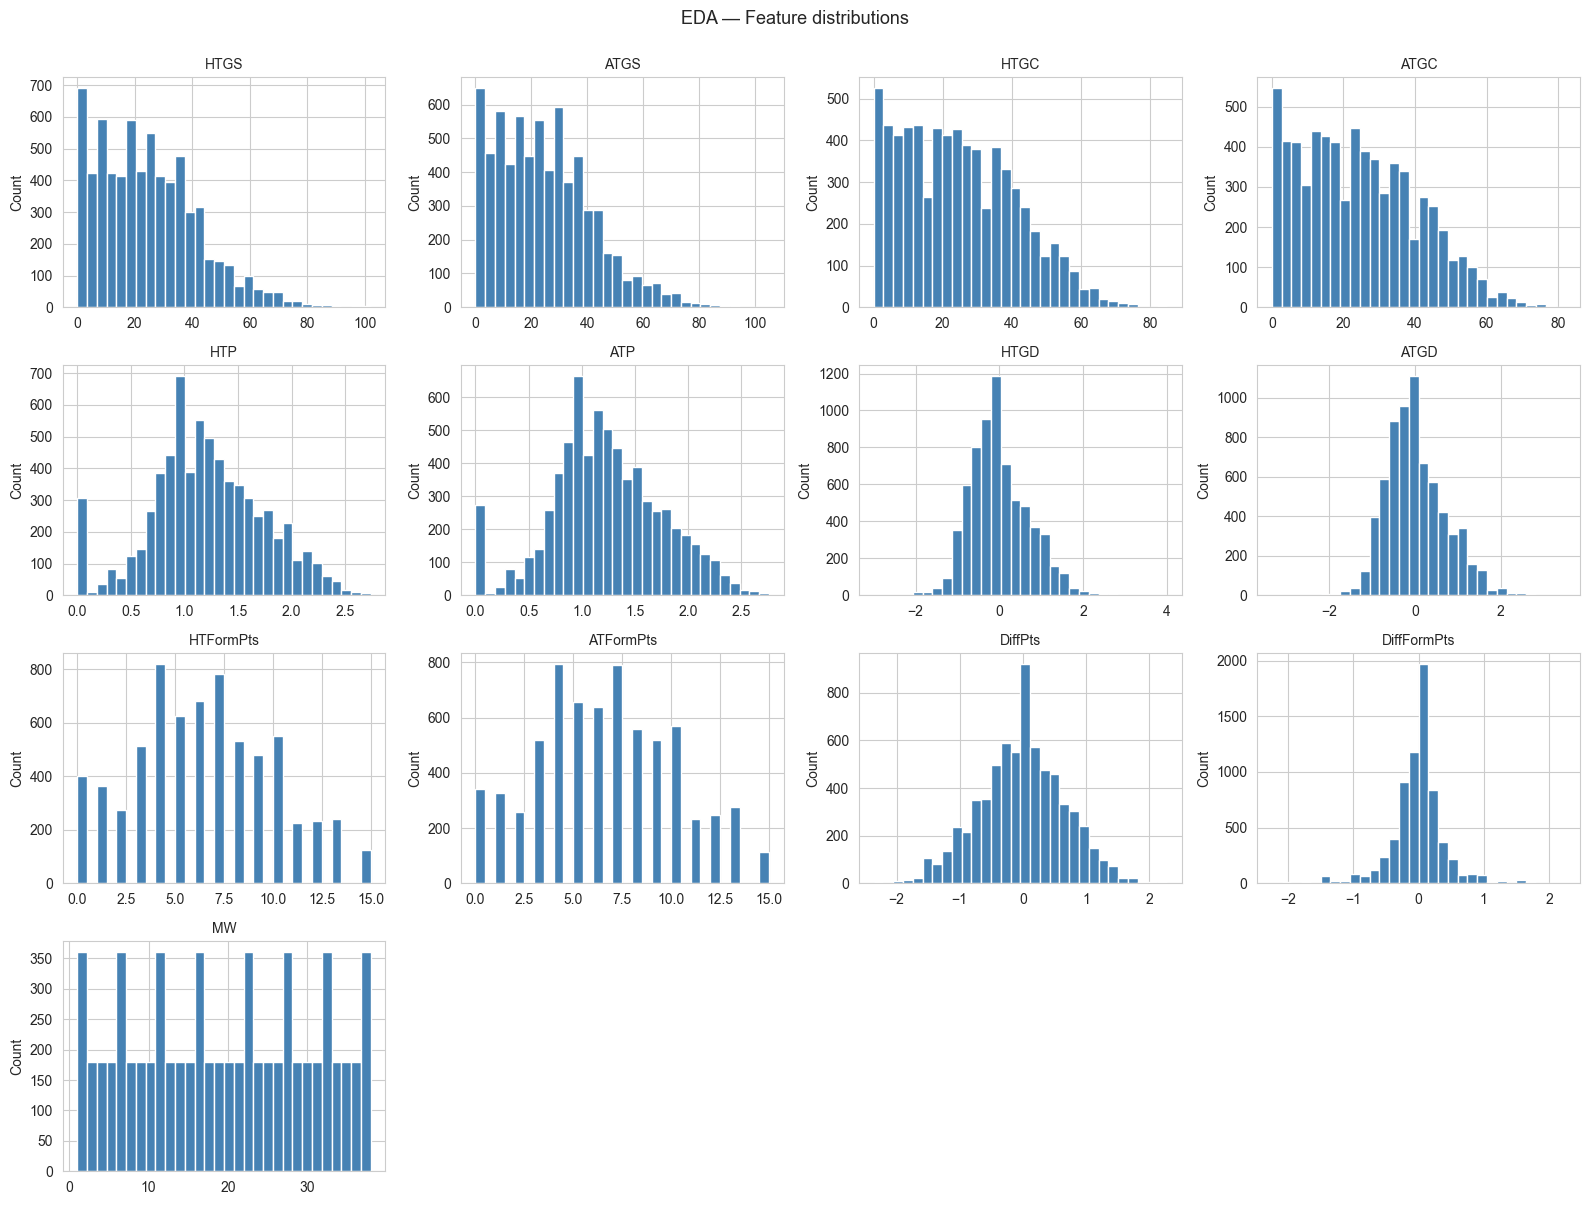

In [10]:
numeric_cols = ['HTGS','ATGS','HTGC','ATGC','HTP','ATP','HTGD','ATGD',
                'HTFormPts','ATFormPts','DiffPts','DiffFormPts','MW']  # all continuous features (streak flags and team IDs excluded — those are categorical)

fig, axes = plt.subplots(4, 4, figsize=(16, 12))  # 4×4 grid: 13 features + 3 empty slots
axes = axes.ravel()                                 # flatten 2D grid to 1D list for easy iteration

for ax, col in zip(axes, numeric_cols):
    ax.hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')  # 30-bin histogram per feature
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Count')
for ax in axes[len(numeric_cols):]: ax.set_visible(False)   # hide the 3 unused subplot slots

plt.suptitle('EDA — Feature distributions', y=1.00, fontsize=13)
plt.tight_layout(); plt.show()

**Findings from Feature Distributions** 

- `HTGS`/`ATGS` are **right-skewed** (skew +0.75, range 0–102) — running goal totals are low early in each season
- `HTGC`/`ATGC` are **moderately right-skewed** (skew +0.44, range 0–85)
- `HTGD`/`ATGD` are **also moderately right-skewed** (skew ~+0.5, range −3.3 to +4.0) — top teams accumulate large positive goal differences faster than bottom teams accumulate equally large negative ones
- `HTP`/`ATP` are **normalized as points-per-match** (range 0–2.74), **roughly symmetric** (skew ~0)
- `MW` (matchweek) is **exactly uniform** (skew 0.0) — every team plays 38 matches per season
- `DiffPts` and `DiffFormPts` are **roughly symmetric around zero** (skew ~−0.03 to −0.16) with moderate spread (±2.3 range)


## Target-vs-Feature Relationships (Boxplots)

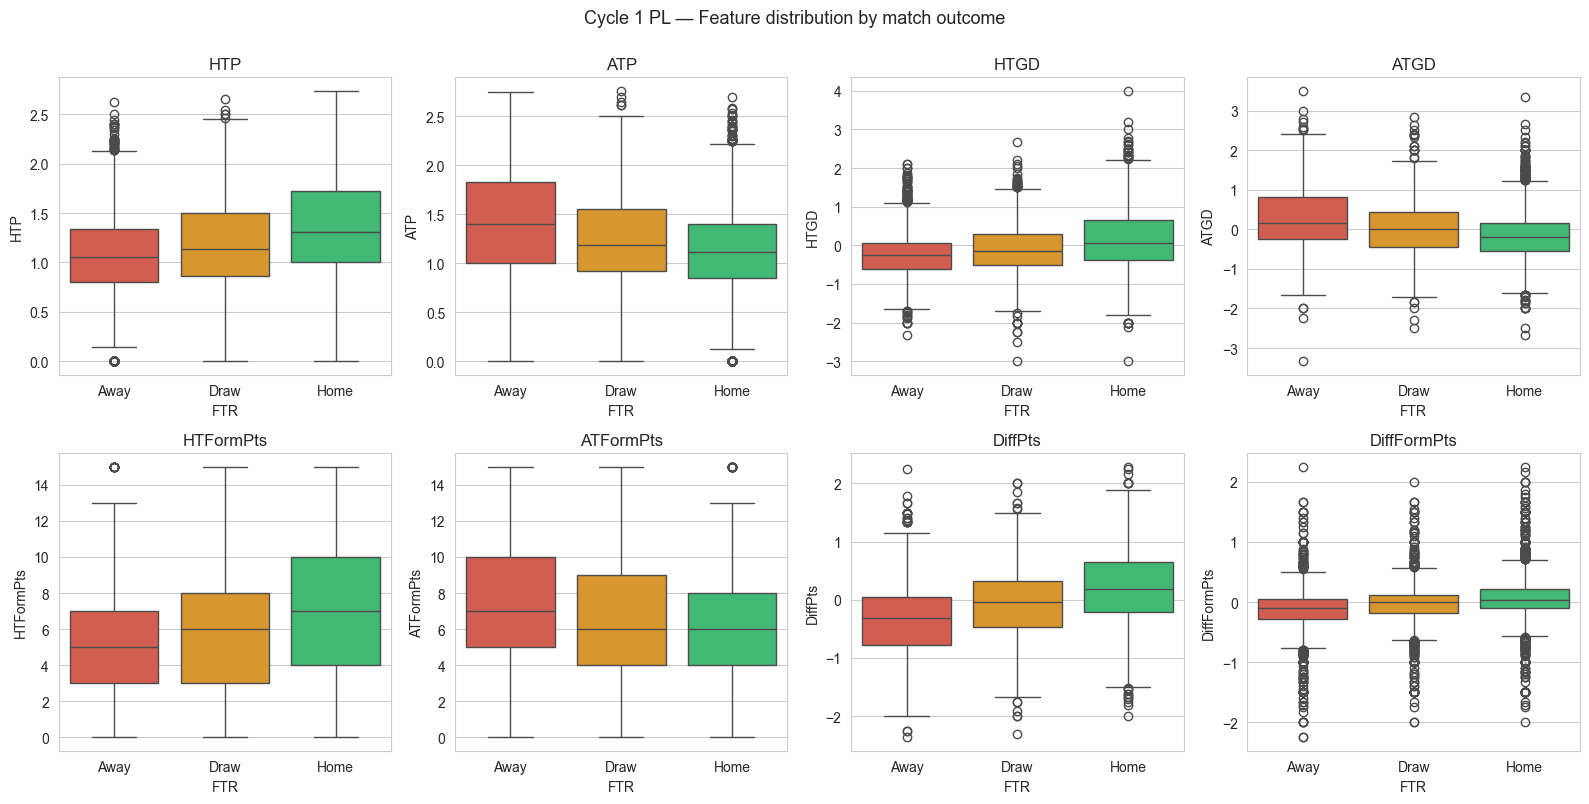

In [11]:
import seaborn as sns
key_features = ['HTP','ATP','HTGD','ATGD','HTFormPts','ATFormPts','DiffPts','DiffFormPts']  # strongest expected predictors of match outcome

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, feat in zip(axes.ravel(), key_features):
    sns.boxplot(data=df, x='FTR', y=feat, ax=ax, palette=['#e74c3c','#f39c12','#2ecc71'])  # one box per outcome: Away/Draw/Home
    ax.set_xticklabels(['Away','Draw','Home'])  # replace integer class labels with readable outcome names
    ax.set_title(feat)

plt.suptitle('Cycle 1 PL — Feature distribution by match outcome', y=1.00, fontsize=13)
plt.tight_layout(); plt.show()

**Findings from box plot**

The box plot shows how each key feature's distribution shifts across the three match outcomes.This step also exposes the "draw collapse" problem — where draws tend to sit in the middle of every distribution, making them structurally harder to predict than Home or Away wins.

## Correlation Heatmap

Measure how each numeric feature is related to the target using Pearson correlation. Also checking how feature relate to one another other.
* If two features are highly correlated, they are basically telling you the same thing (redundant).
* Keeping both can make the model more complex without improving predictions.
* This helps decide which features to remove and explains why models like XGBoost may give high importance to one feature while ignoring similar ones.


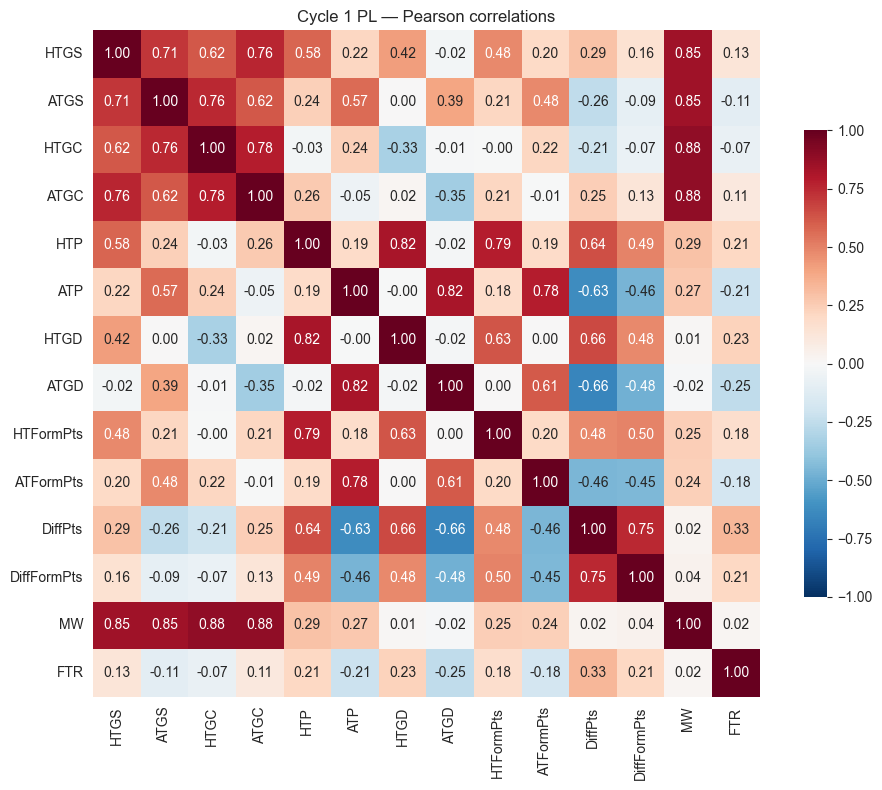

Top correlations with FTR:
  DiffPts        +0.334
  ATGD           -0.251
  HTGD           +0.233
  ATP            -0.212
  HTP            +0.211
  DiffFormPts    +0.210
  ATFormPts      -0.183
  HTFormPts      +0.176


In [12]:
corr_features = numeric_cols + ['FTR']   # include target so we can see feature→outcome correlation strengths
corr = df[corr_features].corr()           # compute full Pearson correlation matrix

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,   # diverging: blue=positive, red=negative
            vmin=-1, vmax=1, square=True, ax=ax, cbar_kws={'shrink':0.7})
ax.set_title('Cycle 1 PL — Pearson correlations')
plt.tight_layout(); plt.show()

print('Top correlations with FTR:')
ftr_corr = corr['FTR'].drop('FTR').abs().sort_values(ascending=False)  # rank features by |correlation| with target
for col, c in ftr_corr.head(8).items():
    print(f'  {col:<14} {corr.loc[col,"FTR"]:+.3f}')   # show signed value so direction is clear (+ = home-biased)

Findings from HeatMap

- **Strong redundancy** between cumulative metrics: `HTP` ↔ `HTGD` correlation is **+0.82** (and `ATP` ↔ `ATGD` = +0.82). Both proxy for team strength 
- **Recent form tracks overall standing tightly**: `HTFormPts` ↔ `HTP` = **+0.79** (and `ATFormPts` ↔ `ATP` = +0.78). Form is not a meaningfully independent signal here
- `DiffPts` has the **single highest correlation with FTR (+0.334)** — that's why it tends to dominate feature importance
- `DiffPts` ↔ `DiffFormPts` = +0.76 — these two are also largely redundant

## Outlier(IQR method)

Find unusual values (outliers) in each numeric feature using the IQR method.

In [13]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])               # compute first and third quartiles
    iqr = q3 - q1                                     # interquartile range
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr          # Tukey fences: standard outlier thresholds
    return ((s < low) | (s > high)).sum(), low, high  # return: count of outliers and the fence values

print(f'{"Feature":<14} {"Outliers":>10} {"Low bound":>12} {"High bound":>12} {"% of rows":>11}')
print('-' * 65)
for col in numeric_cols:
    n, lo, hi = iqr_outliers(df[col])  # apply IQR function to each numeric feature
    print(f'{col:<14} {n:>10} {lo:>12.2f} {hi:>12.2f} {n/len(df)*100:>10.2f}%')

Feature          Outliers    Low bound   High bound   % of rows
-----------------------------------------------------------------
HTGS                   73       -25.00        71.00       1.07%
ATGS                   80       -25.00        71.00       1.17%
HTGC                   11       -26.50        73.50       0.16%
ATGC                   12       -26.50        73.50       0.18%
HTP                    16        -0.11         2.56       0.23%
ATP                    24        -0.08         2.55       0.35%
HTGD                   89        -1.85         1.75       1.30%
ATGD                  105        -1.79         1.75       1.54%
HTFormPts               0        -3.50        16.50       0.00%
ATFormPts               0        -3.50        16.50       0.00%
DiffPts                40        -1.77         1.75       0.58%
DiffFormPts           605        -0.67         0.65       8.85%
MW                      0       -18.50        57.50       0.00%


The IQR method successfully identified extreme values in the dataset. However, applying domain knowledge of football confirms that there are no true data errors (e.g., no negative points, and no Matchweek > 38). The flagged values represent genuine elite performances and extreme team mismatches. Therefore, no rows will be dropped or capped, as doing so would artificially blind the model to how top and bottom teams actually perform.

## Temporal Stability: 

Does the Data Drift Across Seasons?

Check if match outcomes (home win, draw, away win) change over time (2000–2017).

- If the pattern stays the same → random train/test split is fine.
- If the pattern changes → the model might struggle on newer data. - Hence, chronological data spilt. 

        n_matches  home_win_rate  draw_rate  away_win_rate
Season                                                    
2000          380          0.484      0.266          0.250
2001          380          0.434      0.266          0.300
2002          380          0.492      0.237          0.271
2003          380          0.439      0.284          0.276
2004          380          0.455      0.289          0.255
2005          380          0.505      0.203          0.292
2006          380          0.479      0.258          0.263
2007          380          0.463      0.263          0.274
2008          380          0.455      0.255          0.289
2009          380          0.508      0.253          0.239
2010          380          0.471      0.292          0.237
2011          380          0.450      0.245          0.305
2012          380          0.437      0.284          0.279
2013          380          0.471      0.205          0.324
2014          380          0.453      0.245          0.3

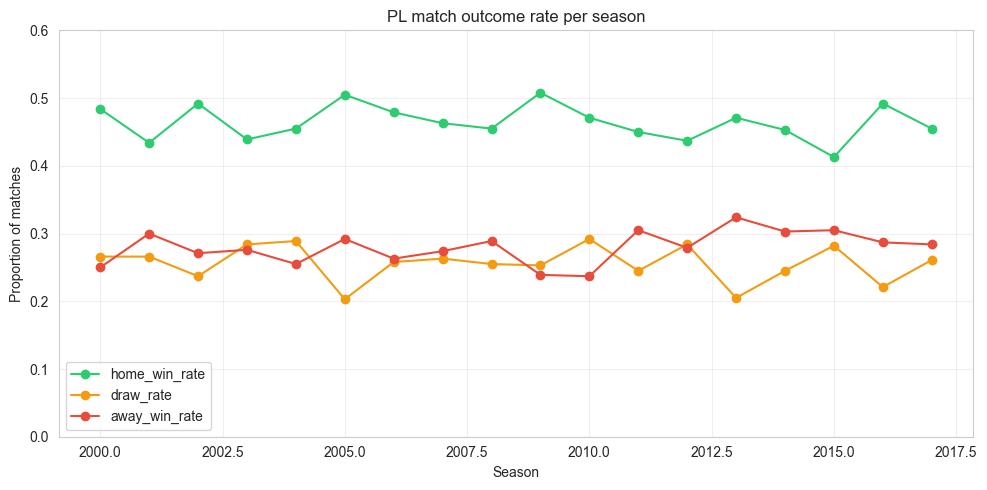

In [14]:
season_summary = df.groupby('Season').agg(
    n_matches    =('FTR','size'),                             # total matches played in that season
    home_win_rate=('FTR', lambda x: (x==2).mean()),          # fraction of matches that ended in a home win
    draw_rate    =('FTR', lambda x: (x==1).mean()),          # fraction of matches that ended in a draw
    away_win_rate=('FTR', lambda x: (x==0).mean()),          # fraction of matches that ended in an away win
).round(3)
print(season_summary)

fig, ax = plt.subplots(figsize=(10,5))
season_summary[['home_win_rate','draw_rate','away_win_rate']].plot(
    ax=ax, marker='o', color=['#2ecc71','#f39c12','#e74c3c'])  # one line per outcome type across seasons
ax.set_title('PL match outcome rate per season')
ax.set_ylabel('Proportion of matches')
ax.set_ylim(0, 0.6)       # fixed y-axis scale for easy cross-season comparison
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Findings Temporal Stability**
- **Home win rate is mildly declining but with high year-to-year noise**. First-3-seasons average ≈ 0.470, last-3-seasons average ≈ 0.454 (drop of ~1.6 percentage points). Spearman correlation with `Season` is only **−0.164** — the trend is weak, not strong
- Per-season home-win rate fluctuates between **0.413** (2015) and **0.508** (2009) — the year-to-year noise (~10pp) is several times larger than the long-term trend (~2pp)
- **Draw rate is roughly flat at 25%** across all seasons
- The drift is small but real, and combined with team-roster turnover (promotions/relegations) it justifies preferring chronological over random splits — the random-split numbers in the deployed model are mildly optimistic, not catastrophically so

## Home Advantage by Team

Check if teams perform better at home, and whether stronger teams benefit more.

Strong teams (like Manchester United or Chelsea F.C.) should win a lot of home games (~65–70%).
Weaker or newly promoted teams should win much less (~20–30%).

If all teams have similar home win rates, then the HomeTeam feature isn’t adding useful information and could be removed.

In [15]:
# Sanity check: home advantage is fundamental to football data — does it hold per team?
team_home_record = df.groupby('HomeTeam').agg(
    home_matches =('FTR','size'),                             # how many home games this team has played (proxy for PL tenure)
    home_win_rate=('FTR', lambda x: (x==2).mean())           # proportion of home games that ended in a home win
).round(3).sort_values('home_win_rate', ascending=False)      # sort best→worst home record

print('Home win rate per team (top 10):')
print(team_home_record.head(10))   # expect: 342 home matches (18 full seasons), ~0.65–0.73 home win rate
print()
print('Home win rate per team (bottom 10):')
print(team_home_record.tail(10))   # expect: few home matches (recently promoted), ~0.20–0.32 home win rate

Home win rate per team (top 10):
          home_matches  home_win_rate
HomeTeam                             
25                 342          0.731
0                  342          0.690
12                 342          0.681
23                 342          0.605
24                 323          0.591
38                 342          0.579
26                  19          0.526
16                 342          0.509
28                 304          0.467
17                 247          0.453

Home win rate per team (bottom 10):
          home_matches  home_win_rate
HomeTeam                             
18                  19          0.316
19                  95          0.305
36                 266          0.305
43                  76          0.303
4                   19          0.263
31                  57          0.263
10                  19          0.263
15                  57          0.246
13                  19          0.211
7                   19          0.211


**Findings** 

Despite using anonymous Team IDs, the dataset passes a structural sanity check by aligning perfectly with real-world football dynamics. The data shows that "Home Advantage" is not a flat boost for all clubs—it scales with team quality. Elite, ever-present clubs (18 seasons) boast a dominant ~70% home win rate, while weaker, frequently relegated clubs (1–5 seasons) win at home only ~30% of the time, proving the dataset's integrity.

### EDA Summary

- This exploratory phase validated the dataset, ensured no data leakage, and identified key patterns relevant to predicting match outcomes.
- The target variable was reconstructed into a 3-class format (Home Win, Draw, Away Win), aligning all analysis with the prediction goal.
- Only pre-match features were retained, and temporal information (Season) was excluded from modelling to prevent leakage.
- Missing values were structurally handled using zero-imputation to represent lack of prior data.
- Feature distributions reflected realistic football dynamics (e.g., skew from elite teams, balanced difference features).
- Strong correlations revealed redundancy, with DiffPts emerging as the most predictive feature.
- Draws were confirmed as inherently harder to predict due to overlapping feature distributions (“draw collapse”).
- Outliers represented valid extreme scenarios and were retained.
- Temporal analysis showed stable draw rates but required chronological splitting to avoid leakage.
- Team-level checks confirmed realistic performance patterns across clubs.

In Conclusion, The dataset is reliable and representative. Match outcomes are primarily driven by relative team strength, feature redundancy must be managed, draws remain challenging, and time-aware validation is essential.